In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import flpoAgent 
import importlib 
import random 
from scipy.spatial.distance import cdist 
import createEnv, MIRS_gurobi_env, MIRS_DOcplex_env, MIRS_scipy_env
from scipy.optimize import Bounds, LinearConstraint, minimize 
import supporting_functions 
from matplotlib.cm import get_cmap 
from matplotlib import cm  # for colormap
import time
import math
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import matplotlib as mpl



n_waypoints: 5 
n_agents: 3 
CAT:
[5. 5. 5. 5. 5.]
---------
wp_locations:
[[  69.76353945  -64.22081502]
 [2410.87264286  -27.69231078]
 [4955.08018572    6.00004498]
 [ -38.81621685 2460.89487183]
 [2422.34825524 2449.97980278]] 
mask:
[[0 1 0 1 0]
 [1 0 1 0 1]
 [0 1 0 0 0]
 [1 0 0 0 1]
 [0 1 0 1 0]] 
dist_mat:
[[1.00000000e+08 2.34139406e+03 1.00000000e+08 2.52744907e+03
  1.00000000e+08]
 [2.34139406e+03 1.00000000e+08 2.54443062e+03 1.00000000e+08
  2.47769869e+03]
 [1.00000000e+08 2.54443062e+03 1.00000000e+08 1.00000000e+08
  1.00000000e+08]
 [2.52744907e+03 1.00000000e+08 1.00000000e+08 1.00000000e+08
  2.46118868e+03]
 [1.00000000e+08 2.47769869e+03 1.00000000e+08 2.46118868e+03
  1.00000000e+08]] 
wp_weights:
[0.2 0.2 0.2 0.2 0.2]
---------
agent_weights:
[0.33333333 0.33333333 0.33333333] 
sd_mat:
[[2 3]
 [2 3]
 [3 2]] 
eta_arr: 
processing_time:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]] 
speed_lim_mat:
[[ 0.9184536  78.65715034]
 [ 0.27150538 78.07079482]
 [ 0.

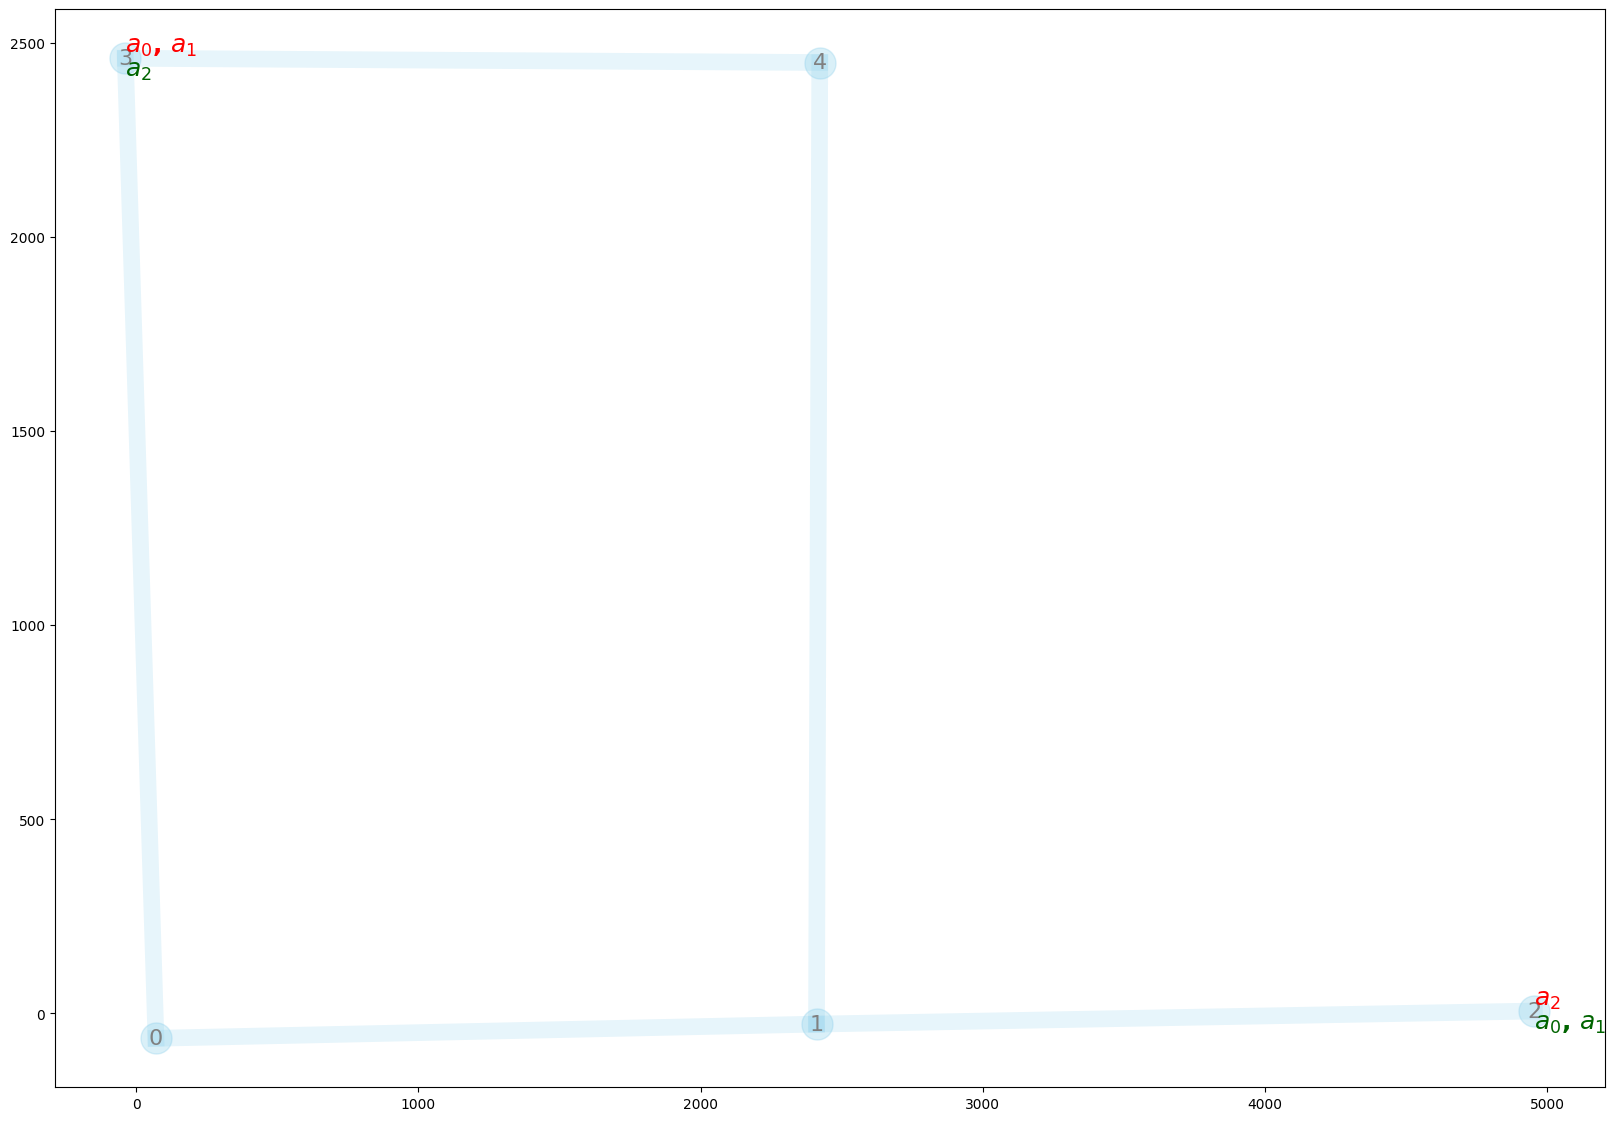

In [2]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 3
n_agents = 1
tolArray = np.random.uniform(5.0, 5.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':5000,
    'noise_factor':100,
    'extra_connections':0
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.3,
    'missing_connections':0.05
}

multigraph_params = {
    'type':'multigraph',
    'n_points':n_waypoints,
    'n_graphs':4,
    'grid_size':10000.0,
    'intra_graph_connectivity':0.2,
    'inter_graph_connectivity':0.01,
    'subgraph_type':'grid',
    'seed':None
}

# ellispoid cbf mode
ca_cbf_el = {
    'mode':'ellipse',
    'major_axis':1e-3*tolArray,
    'minor_axis':1e-4*tolArray,
    'degree':2
}

# rectangular cbf mode
ca_cbf_rect = {
    'mode':'rect',
    'width':1e-3*tolArray,
    'height':1e-4*tolArray,
    'gamma':1,
    'width_correction_fac':0.5,
    'height_correction_fac':0.5
}

# linear cbf mode
ca_cbf_lin = {
    'mode':'linear',
    'eps':1e-4*tolArray,
    'eta':0
}

# cost mode options
cost_mode = 'sum' # 'slowest'
lm = 1 # for slowest

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    grid_params,
    seed=15,
    offset_energy=1,
    stagewiseCostCoeffs=np.array([1.0, 100.0, 1.0]),
    selfHop=0,
    ca_cbf=ca_cbf_rect,
    cost_mode=cost_mode,
    lm = lm,
    filter_wp_thresh=1e-10,
    prune_mode=False,
    printFlag=True)

# mars visualization 
cmap = plt.get_cmap('tab20') 
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))} 
createEnv.plotNetwork(mars=mars, figuresize=(20,14), routes=[], agent_colors=agent_colors, showEdgeLength=False) 

# Prepare to save
dir_name = '/Users/dhananjaytiwari/Documents/NASA_ULI/MIRS_Journal/MIRS_Results'
scene_name = multigraph_params['type'] + f'Nw{n_waypoints}_Na{n_agents}'

In [3]:

gurobi_distMat = cdist(mars.wp_locations, mars.wp_locations, 'euclidean') 
min_inv_speed = 1/np.max(mars.speed_lim_mat) 
max_inv_speed = 1/np.min(mars.speed_lim_mat) 


In [4]:

# initialize stage sizes 
stage_sizes = [] 
K = mars.n_waypoints+1 
for k in range(K+1):
    if k == 0 or k == K:
        stage_sizes.append(1)
    else:
        stage_sizes.append(mars.n_waypoints)
print(f"stage_sizes:{stage_sizes}")
print(f"inverse speed range: ({min_inv_speed:.3e},\t{max_inv_speed:.3e})")


stage_sizes:[1, 5, 5, 5, 5, 5, 1]
inverse speed range: (1.271e-02,	3.683e+00)


### Solve using Gurobi

In [5]:

mirs_gb = MIRS_gurobi_env.MIRS_Gurobi(
        num_agents = mars.n_agents,
        num_waypoints = mars.n_waypoints,
        start_goal = mars.sd_mat,
        theta_bounds = (0, mars.T_upper_bound),
        inv_speed_bounds = (min_inv_speed, max_inv_speed),
        INF = mars.INF,
        stage_sizes = stage_sizes,
        mask = mars.mask,
        start_times = mars.start_times,
        distMat = gurobi_distMat,
        tolerance = mars.tolArray,
        stagewiseCostCoeffs = mars.stagewiseCostCoeffs
)


Set parameter Username
Set parameter LicenseID to value 2781143
Academic license - for non-commercial use only - expires 2027-02-19
Set parameter NonConvex to value 2


In [6]:
mirs_gb.optimize(stagnation_limit=10000)

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 600
Set parameter MIPGap to value 0.05
Set parameter MIPFocus to value 1
Set parameter Heuristics to value 0.8
Set parameter Cuts to value 2
Set parameter OBBT to value 2
Set parameter NumericFocus to value 2
Set parameter Presolve to value 2
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.05
Heuristics  0.8
MIPFocus  1
OBBT  2
Cuts  2
NonConvex  2
NumericFocus  2
Presolve  2

Optimize a model with 347 rows, 1008 columns and 566 nonzeros
Model fingerprint: 0x4c9a48d3
Model has 469 quadratic constraints
Variable types: 678 continuous, 330 integer (330 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 7e+08]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 6e+02]
  Bounds range     [1e-

In [8]:
agent_routes, agent_schedules, schedule_matrix, association_matrix = mirs_gb.extract_routes_and_schedules()

[0.0, 0.41903854840671345, 32.40082173960367, 64.63384864007062, 96.69661909781496] 2
[0.0, 0.41903854840671345, 32.40082173960367, 64.63384864007062, 96.69661909781496] 3
[0.0, 0.41903854840671345, 32.40082173960367, 64.63384864007062, 96.69661909781496] 4
[0.0, 10.15720696837874, 43.094712752262886, 75.26118757602292, 108.2680870105208] 2
[0.0, 10.15720696837874, 43.094712752262886, 75.26118757602292, 108.2680870105208] 3
[0.0, 10.15720696837874, 43.094712752262886, 75.26118757602292, 108.2680870105208] 4
[0.0, 0.021400614118909773, 30.350324415804348, 63.35639252574072, 95.70476694017049] 2
[0.0, 0.021400614118909773, 30.350324415804348, 63.35639252574072, 95.70476694017049] 3
[0.0, 0.021400614118909773, 30.350324415804348, 63.35639252574072, 95.70476694017049] 4


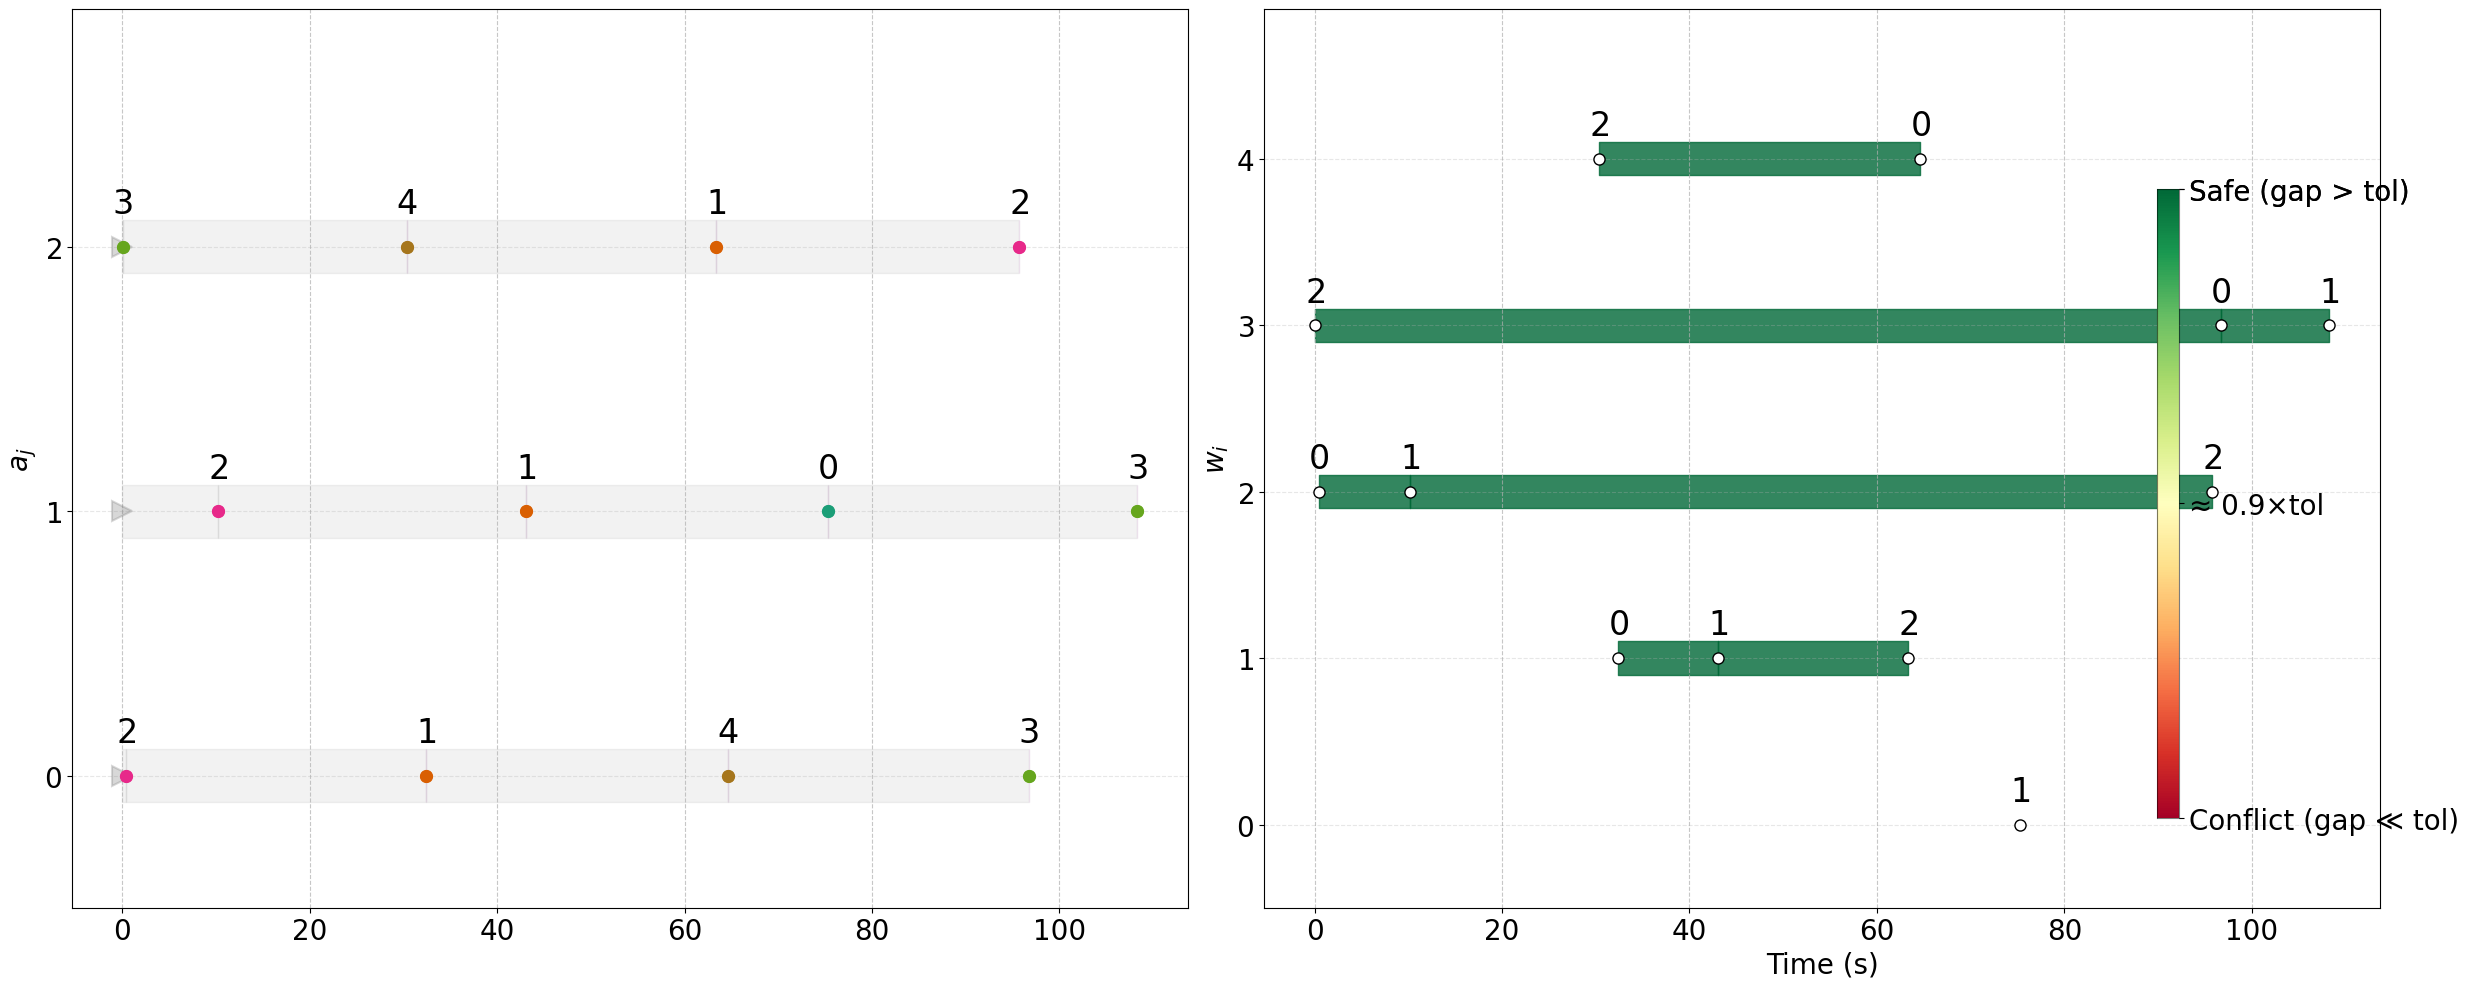

In [12]:
mirs_gb.plot_waypoint_agent_schedules(
    agent_routes,
    agent_schedules,
    np.array(schedule_matrix),
    np.array(association_matrix),
    mars.process_T,
    mars.tolArray,
    agent_colors,
    figuresize=(24,10),
)

